### Multivariate Linear Regression (다변량 선형 회귀)
- 하나의 종속변수와 여러 독립변수 사이의 관계를 분석하는 기법이다.

In [1]:
import pandas as pd

a_df = pd.read_csv('./datasets/advertising.csv')
a_df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [2]:
pre_a_df = a_df.drop(labels=['Unnamed: 0'], axis=1)
pre_a_df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


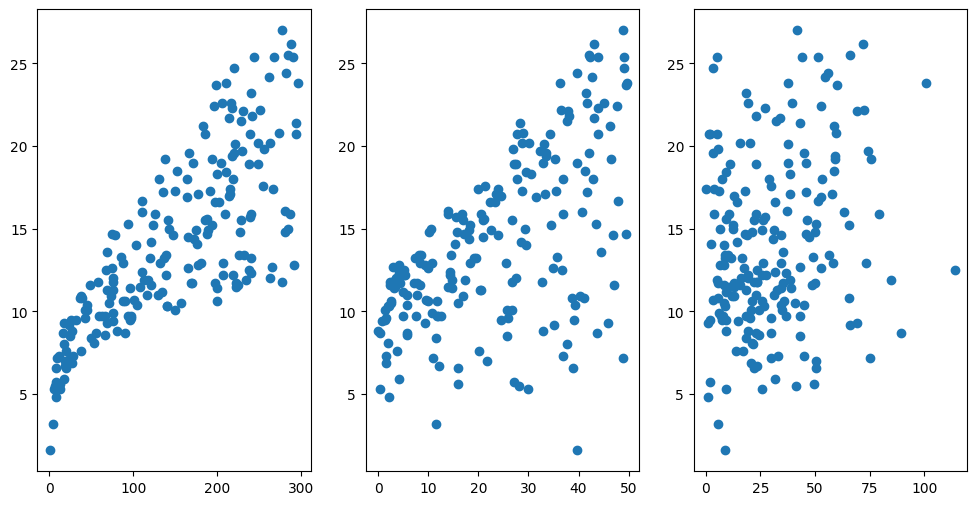

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(12, 6))

ax[0].scatter(pre_a_df.TV, pre_a_df.Sales)
ax[1].scatter(pre_a_df.Radio, pre_a_df.Sales)
ax[2].scatter(pre_a_df.Newspaper, pre_a_df.Sales)
plt.show()

In [4]:
pre_a_df.iloc[:, :-1].corr()

,TV,Radio,Newspaper
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Newspaper,0.056648,0.354104,1.000000


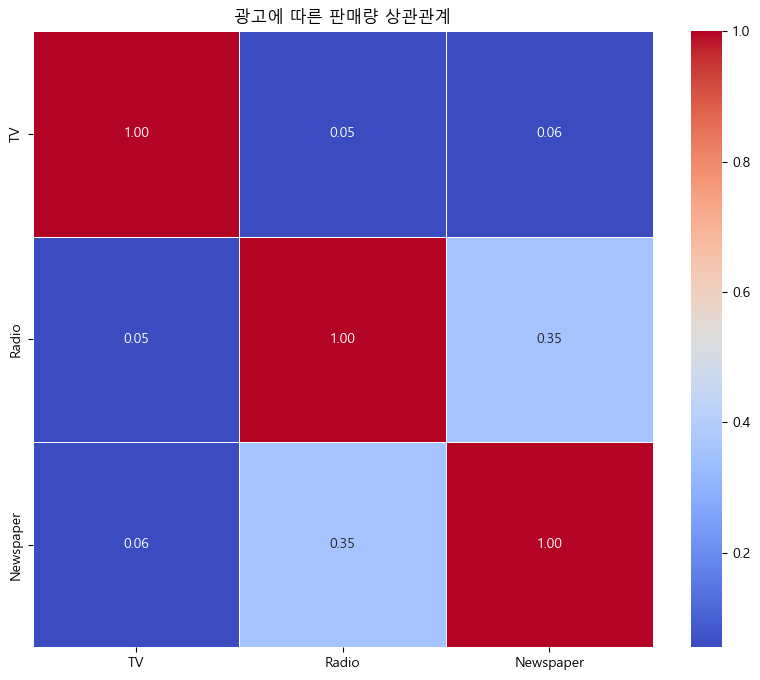

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상관계수 계산
corr = pre_a_df.iloc[:, :-1].corr()

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('광고에 따른 판매량 상관관계')
plt.show()

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features, targets = pre_a_df.iloc[:, :-1], pre_a_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

l_r = LinearRegression()
l_r.fit(X_train, y_train)
print('W1: {:.4f}, W2: {:.4f}, W3: {:.4f} b: {:.4f}'\
      .format(l_r.coef_[0], l_r.coef_[1], l_r.coef_[2], l_r.intercept_))
# 결과 분석: TV 분포가 더 좋아보이는데 왜 Radio에 가중치가 더 높지?

W1: 0.0448, W2: 0.1937, W3: 0.0050 b: 2.8103


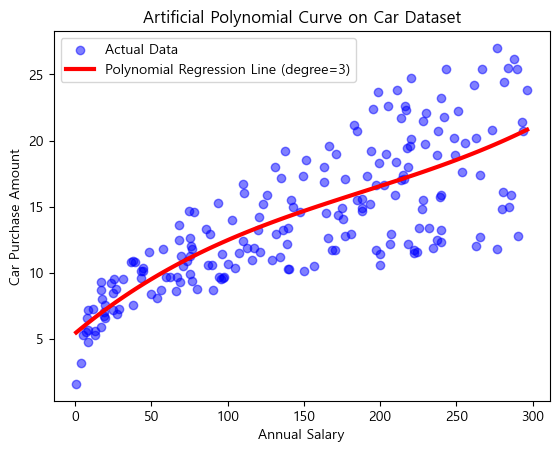

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# 시각화를 위해 변수 하나만 사용
X = features[['TV']] 

# 1. 다항 회귀 변환 (3차식)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X.values)

# 2. 모델 학습
l_r_poly = LinearRegression()
l_r_poly.fit(X_poly, targets)

# 3. 매끄러운 곡선을 그리기 위한 임의의 데이터 생성
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_ped_poly = l_r_poly.predict(x_range_poly)

# 4. 시각화
plt.scatter(X, targets, color='blue', alpha=0.5, label='Actual Data')
plt.plot(x_range, y_ped_poly, color='red', linewidth=3, label='Polynomial Regression Line (degree=3)') # 이게 곡선입니다!
plt.xlabel('Annual Salary')
plt.ylabel('Car Purchase Amount')
plt.title('Artificial Polynomial Curve on Car Dataset')
plt.legend()
plt.show()

In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

def get_evaluation(y_test, prediction):
    MAE =  mean_absolute_error(y_test, prediction)
    MSE = mean_squared_error(y_test, prediction)
    RMSE = np.sqrt(MSE)
    MSLE = mean_squared_log_error(y_test, prediction)
    RMSLE = np.sqrt(mean_squared_log_error(y_test, prediction))
    R2 = r2_score(y_test, prediction)

    print('MAE: {:.4f}, MSE: {:.4f}, RMSE: {:.4f}, MSLE: {:.4f}, RMSLE: {:.4f}, R2: {:.4f}'.format(MAE, MSE, RMSE, MSLE, RMSLE, R2))

In [10]:
get_evaluation(y_test, l_r.predict(X_test))

MAE: 1.3845, MSE: 3.5016, RMSE: 1.8713, MSLE: 0.0356, RMSLE: 0.1886, R2: 0.8850


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF < 5: 매우 양호 (독립성이 높음)
# VIF < 10: 수용 가능 (약간의 상관관계가 있으나 문제없음)
# VIF > 10: 위험 (다중공선성 존재, 변수 제거 또는 처리가 필요함)
# 만약 어떤 변수의 VIF가 20 ~ 30이라면, 그 변수는 빼거나 다른 것과 합쳐서 해결한다.
def feature_engineering_VIF(features):
    vif = pd.DataFrame()
    vif['vif_score'] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
    vif['feature'] = features.columns
    return vif

In [12]:
feature_engineering_VIF(features)

,vif_score,feature
0,2.486772,TV
1,3.285462,Radio
2,3.055245,Newspaper


In [13]:
features

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [17]:
### from sklearn.preprocessing import StandardScaler

# 모든 변수의 단위를 평균 0, 표준편차 1로 맞춤
scaler = StandardScaler()
# 학습 데이터를 기준으로 학습(fit)
X_train_scaled = scaler.fit_transform(X_train.values)
# 학습 데이터를 기준으로 변환(transform)
X_test_scaled = scaler.transform(X_test.values)

l_r_scaled = LinearRegression()
l_r_scaled.fit(X_train_scaled, y_train)
prediction = l_r_scaled.predict(X_test_scaled)

print('Standardized Coefficients:', l_r_scaled.coef_)
# 결과 분석: TV 가중치가 높게 나옴

Standardized Coefficients: [3.71814003 2.82415939 0.10442125]


In [18]:
get_evaluation(y_test, prediction)

MAE: 1.3845, MSE: 3.5016, RMSE: 1.8713, MSLE: 0.0356, RMSLE: 0.1886, R2: 0.8850


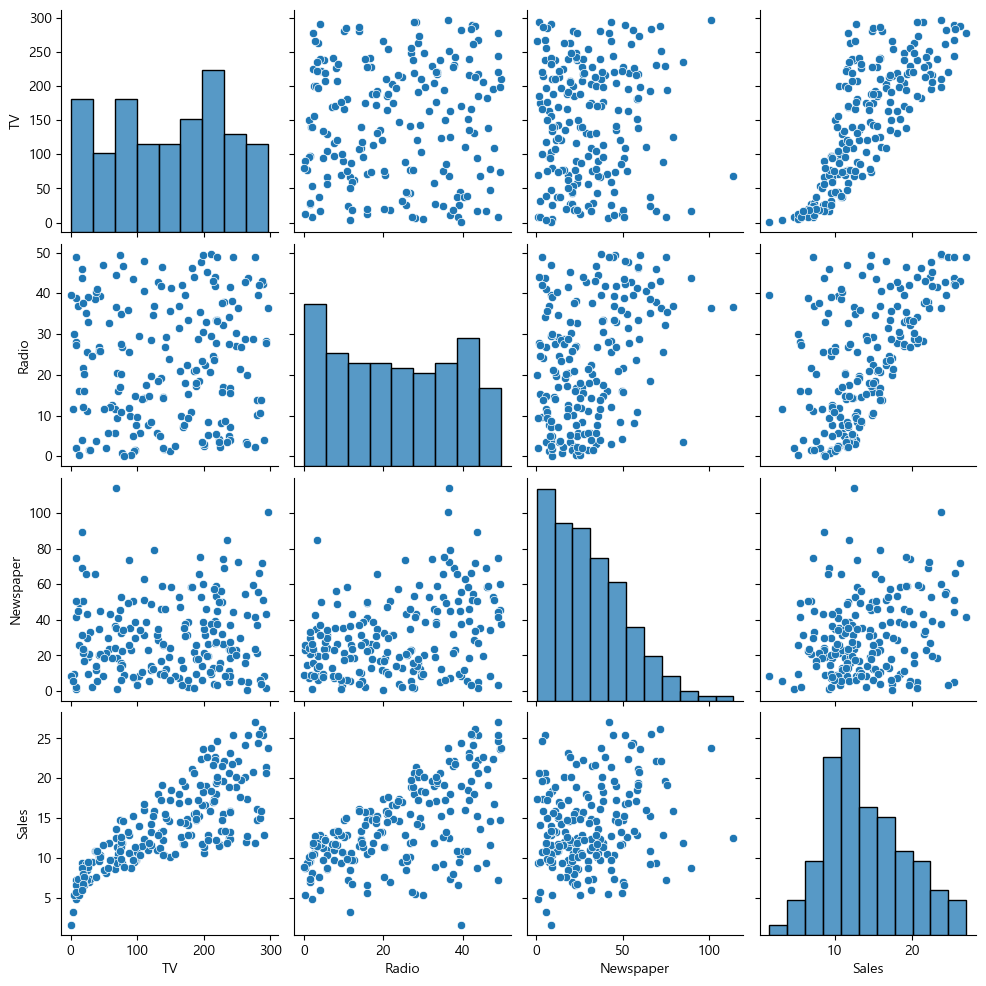

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(pre_a_df)
plt.show()

#### 비선형 모델로 교체

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

features, targets = pre_a_df.iloc[:, :-1], pre_a_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

dt_reg = DecisionTreeRegressor(random_state=124)
dt_reg.fit(X_train.values, y_train)
prediction = dt_reg.predict(X_test.values)

In [22]:
get_evaluation(y_test, prediction)

MAE: 0.8900, MSE: 1.5010, RMSE: 1.2252, MSLE: 0.0115, RMSLE: 0.1073, R2: 0.9507


In [23]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import randint

features, targets = pre_a_df.iloc[:, :-1], pre_a_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

# RandomizedSearchCV 설정
parameters = {
    'max_depth': randint(2, 10),      # 2부터 10 사이의 정수를 랜덤하게 추출
    'min_samples_split': randint(2, 20) # 2부터 20 사이의 정수를 랜덤하게 추출
}

dtr = DecisionTreeRegressor(random_state=124)

# n_iter: 전체 조합 중 몇 개의 조합을 랜덤하게 뽑아 실행할지 결정 (여기서는 4개 선택)
# cv=3이므로 총 4(n_iter) * 3(cv) = 12번의 훈련이 진행됨
random_grid_decision_tree = RandomizedSearchCV(
    dtr, 
    param_distributions=parameters, 
    n_iter=4, 
    cv=3, 
    refit=True, 
    return_train_score=True,
    random_state=124 # 실행 시마다 동일한 결과를 위해 추가
)

# 학습
random_grid_decision_tree.fit(X_train_scaled, y_train)

,estimator,DecisionTreeR...dom_state=124)
,param_distributions,"{'max_depth': <scipy.stats....0019FB6CBC880>, 'min_samples_split': <scipy.stats....0019FB6F4FA30>}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,124
,error_score,nan


In [24]:
import pandas as pd

random_scores_df = pd.DataFrame(random_grid_decision_tree.cv_results_)
random_scores_df[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
1,"{'max_depth': 9, 'min_samples_split': 4}",0.935873,1
3,"{'max_depth': 6, 'min_samples_split': 16}",0.880617,2
0,"{'max_depth': 8, 'min_samples_split': 19}",0.877948,3
2,"{'max_depth': 3, 'min_samples_split': 2}",0.844271,4


In [25]:
parameters = {'max_depth':list(range(3, 10)), 'min_samples_split':list(range(2, 20))}

grid_dtr = GridSearchCV(dtr, param_grid=parameters, cv=3, refit=True, return_train_score=True)
grid_dtr.fit(X_train_scaled, y_train)

,estimator,DecisionTreeR...dom_state=124)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'squared_error'


In [26]:
import pandas as pd

grid_scores_df = pd.DataFrame(grid_dtr.cv_results_)
grid_scores_df[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
91,"{'max_depth': 8, 'min_samples_split': 3}",0.937900,1
72,"{'max_depth': 7, 'min_samples_split': 2}",0.937597,2
109,"{'max_depth': 9, 'min_samples_split': 3}",0.937474,3
74,"{'max_depth': 7, 'min_samples_split': 4}",0.936274,4
92,"{'max_depth': 8, 'min_samples_split': 4}",0.936011,5
...,...,...,...
14,"{'max_depth': 3, 'min_samples_split': 16}",0.835727,118
13,"{'max_depth': 3, 'min_samples_split': 15}",0.835727,118
12,"{'max_depth': 3, 'min_samples_split': 14}",0.835727,118
11,"{'max_depth': 3, 'min_samples_split': 13}",0.835727,118


In [27]:
dtr = grid_dtr.best_estimator_
prediction = dtr.predict(X_test_scaled)
get_evaluation(y_test, prediction)

MAE: 0.7819, MSE: 1.0470, RMSE: 1.0232, MSLE: 0.0154, RMSLE: 0.1241, R2: 0.9656


In [28]:
dtr.feature_importances_

array([0.60664228, 0.39164016, 0.00171756])